# plotting PCAs

This notebook generate PCA plots for Single Cell datasets

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")

Git root directory: /Users/kaylorhuang/Documents/GitHub_Repos/Kaylor---NF1_organoid_profile_analysis 


In [3]:
figures_path <- file.path(root_dir,"1.EDA/figures/pca")
if (!dir.exists(figures_path)) {
  dir.create(figures_path, recursive = TRUE)
}

In [4]:
# Load PCA results, # Recode STAURO to Staurosporine in the dataframes
# Single-cell (sc) PCA results
max_projection_2D_sc_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/max_projection/sc_fs_pca.parquet"))
max_projection_2D_sc_pca_results <- max_projection_2D_sc_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

sc_3D_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/3D/sc_fs_pca.parquet"))
sc_3D_pca_results <- sc_3D_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

middle_slice_2D_sc_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/middle_slice/sc_fs_pca.parquet"))
middle_slice_2D_sc_pca_results <- middle_slice_2D_sc_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

# Aggregate (agg) PCA results
max_projection_2D_agg_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/max_projection/sc_agg_pca.parquet"))
max_projection_2D_agg_pca_results <- max_projection_2D_agg_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

agg_3D_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/3D/sc_agg_pca.parquet"))
agg_3D_pca_results <- agg_3D_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

middle_slice_2D_agg_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/middle_slice/sc_agg_pca.parquet"))
middle_slice_2D_agg_pca_results <- middle_slice_2D_agg_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

# Consensus PCA results
max_projection_2D_cp_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/max_projection/sc_consensus_pca.parquet"))
max_projection_2D_cp_pca_results <- max_projection_2D_cp_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

cp_3D_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/3D/sc_consensus_pca.parquet"))
cp_3D_pca_results <- cp_3D_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

middle_slice_2D_cp_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/middle_slice/sc_consensus_pca.parquet"))
middle_slice_2D_cp_pca_results <- middle_slice_2D_cp_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

In [5]:
# Set custom colors for each treatment
custom_treatment_palette <- c(
    'DMSO' = "#5a5c5d",              # Control - gray
    'Staurosporine' = "#7D2780",     # Dark purple
    
    'Fimepinostat' = "#1E6B61",      # Teal (HDAC inhibitor)
    'Copanlisib' = "#0092E0",        # Blue (PI3K inhibitor)
    
    'Imatinib' = "#576A20",          # Olive green
    'Nilotinib' = "#646722",         # Yellow-green
    'Cabozantinib' = "#758B2D",      # Light olive
    
    'Everolimus' = "#ACE089",        # Light green (mTOR inhibitor)
    'Rapamycin' = "#90D070",         # Medium green (mTOR inhibitor)
    'Linsitinib' = "#ACE040",        # Yellow-green (IGF-1R inhibitor)
    
    'Onalespib' = "#33206A",         # Dark purple (HSP90 inhibitor)
    'Digoxin' = "#A16C28",           # Orange-brown
    'Ketotifen' = "#3A8F00",         # Green
    
    'Binimetinib' = "#ff0000",       # Red (MEK inhibitor)
    'Mirdametinib' = "#cc0000",      # Dark red (MEK inhibitor)
    'Trametinib' = "#ff3333",        # Light red (MEK inhibitor)
    'Selumetinib' = "#ff6666"        # Lighter red (MEK inhibitor)
)

In [6]:
pca_theme <- theme(
        plot.title = element_text(hjust = 0.5, size = 16),
        axis.title.x = element_text(size = 14),
        axis.title.y = element_text(size = 14),
        legend.title = element_text(size = 14, hjust = 0.5),
        legend.text = element_text(size = 12)
    )

## 2D MIP PCA

feature selected facet by patients

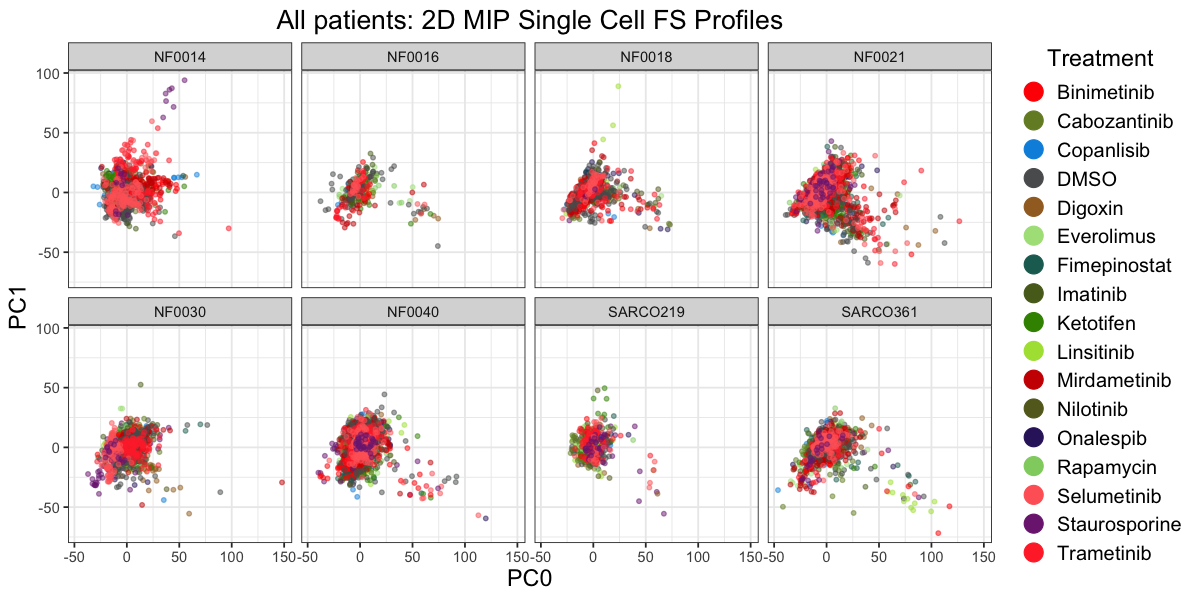

In [7]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D MIP Single Cell FS Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
    + facet_wrap(~Metadata_patient, nrow = 2)
)
pca_2D_sc_mip_faceted_path <- file.path(figures_path, "2D", "max_projection", "all_patients_2D_MIP_pca_sc_features_facet_by_patient.png")
ggsave(pca_sc_plot, file = pca_2D_sc_mip_faceted_path, width = width, height = height, dpi = 300)
pca_sc_plot

feature selected

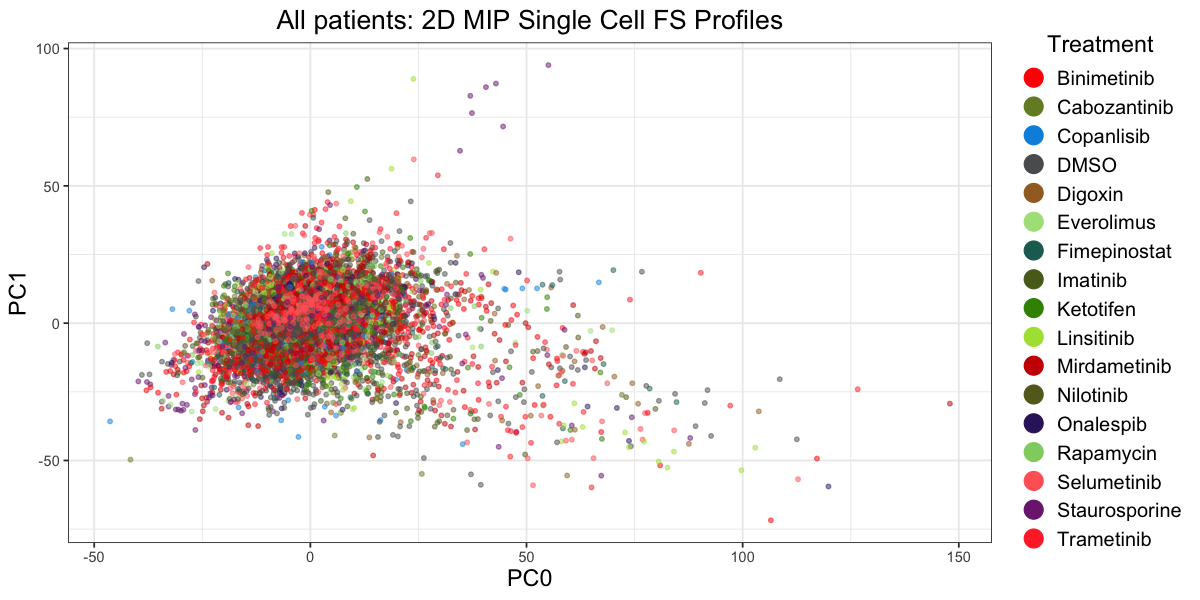

In [8]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D MIP Single Cell FS Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_sc_mip_path <- file.path(figures_path, "2D", "max_projection","all_patients_2D_MIP_pca_sc_features.png")
ggsave(pca_sc_plot, file = pca_2d_sc_mip_path, width = width, height = height, dpi = 300)
pca_sc_plot

aggregate Profiles

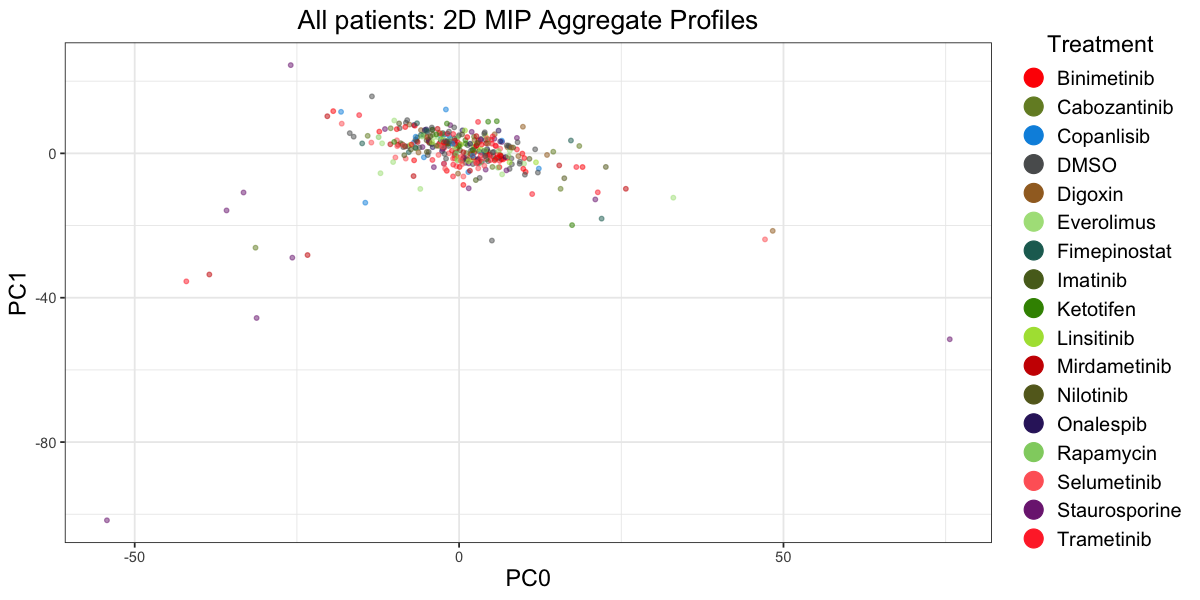

In [9]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)

pca_agg_mip_plot <- (
    ggplot(max_projection_2D_agg_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D MIP Aggregate Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme
    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_agg_mip_path <- file.path(figures_path,"2D", "max_projection", "all_patients_2D_MIP_pca_agg_features.png")
ggsave(pca_agg_mip_plot, file = pca_2d_agg_mip_path, width = width, height = height, dpi = 300)
pca_agg_mip_plot

consensus profiles

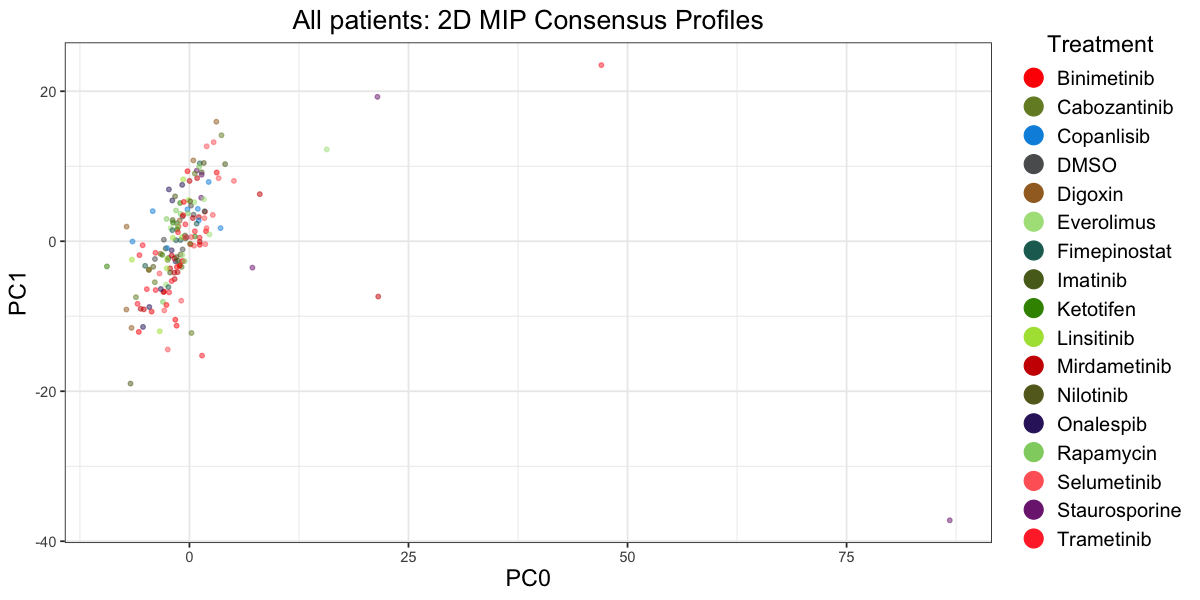

In [10]:
pca_cp_mip_plot <- (
    ggplot(max_projection_2D_cp_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D MIP Consensus Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme
    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_cp_mip_path <- file.path(figures_path,"2D", "max_projection", "all_patients_2D_MIP_pca_consensus_features.png")
ggsave(pca_cp_mip_plot, file = pca_2d_cp_mip_path, width = width, height = height, dpi = 300)
pca_cp_mip_plot

## 2D Middle Slice

feature selected facet by patients

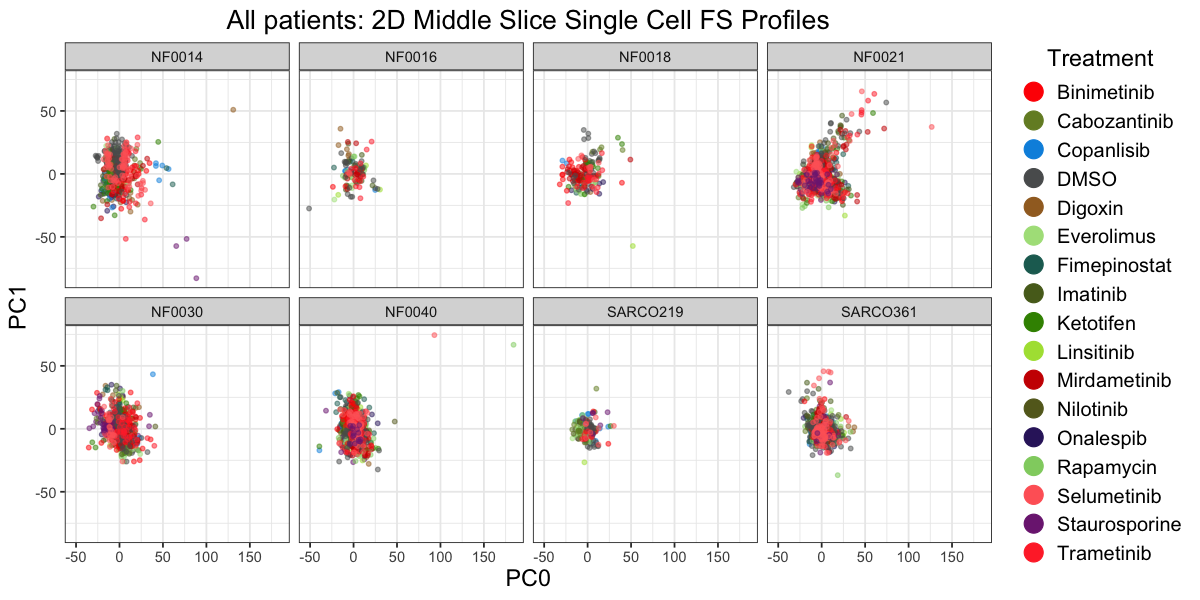

In [11]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(middle_slice_2D_sc_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D Middle Slice Single Cell FS Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
    + facet_wrap(~Metadata_patient, nrow = 2)
)
pca_2d_sc_middle_slice_faceted_path <- file.path(figures_path, "2D", "middle_slice", "all_patients_2D_middle_slice_pca_sc_features_facet_by_patient.png")
ggsave(pca_sc_plot, file = pca_2d_sc_middle_slice_faceted_path, width = width, height = height, dpi = 300)
pca_sc_plot

feature selected

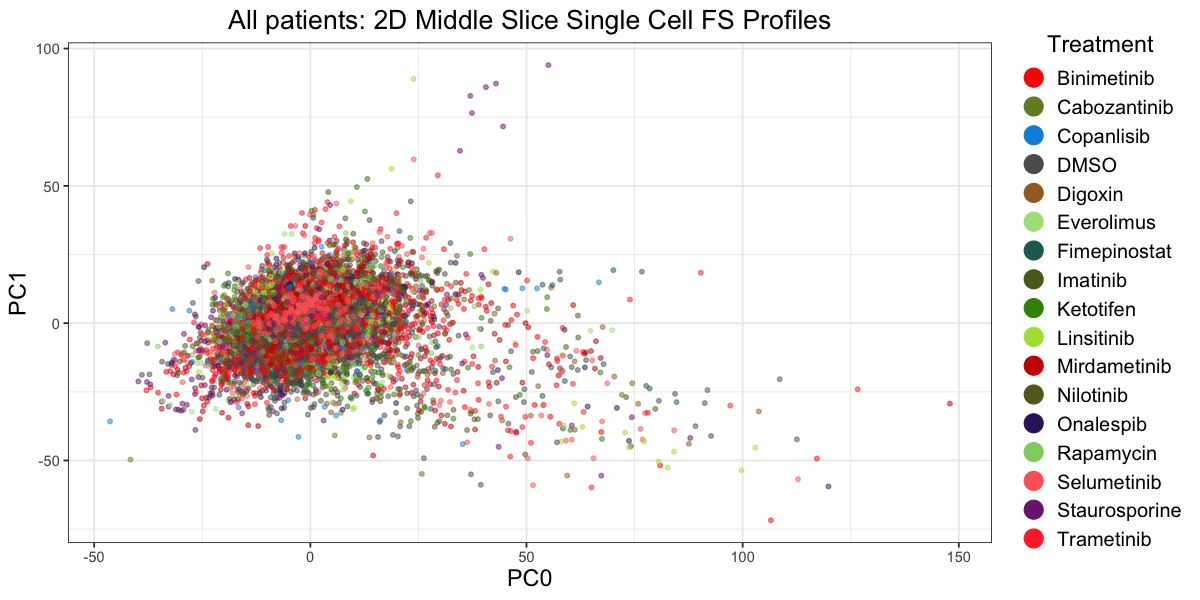

In [12]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D Middle Slice Single Cell FS Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_sc_middle_slice_path <- file.path(figures_path, "2D", "middle_slice", "all_patients_2D_middle_slice_pca_sc_features.png")
ggsave(pca_sc_plot, file = pca_2d_sc_middle_slice_path, width = width, height = height, dpi = 300)
pca_sc_plot

aggregate profiles

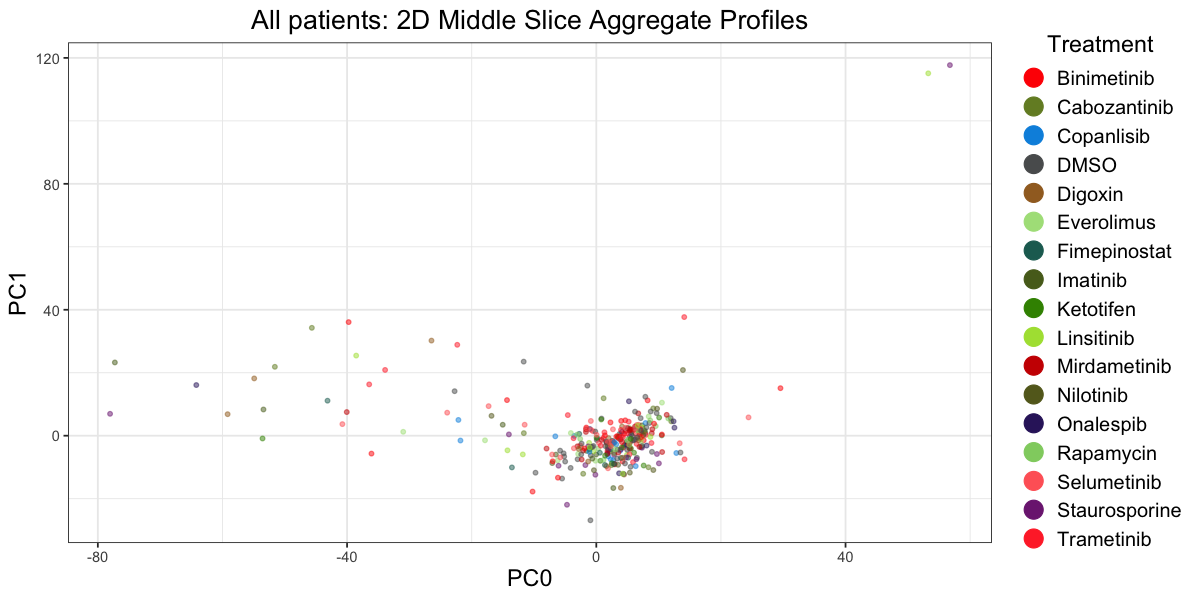

In [13]:
pca_agg_middle_plot <- (
    ggplot(middle_slice_2D_agg_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D Middle Slice Aggregate Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme
    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_agg_middle_path <- file.path(figures_path, "2D", "middle_slice", "all_patients_2D_middle_slice_pca_agg_features.png")
ggsave(pca_agg_middle_plot, file = pca_2d_agg_middle_path, width = width, height = height, dpi = 300)
pca_agg_middle_plot


consensus

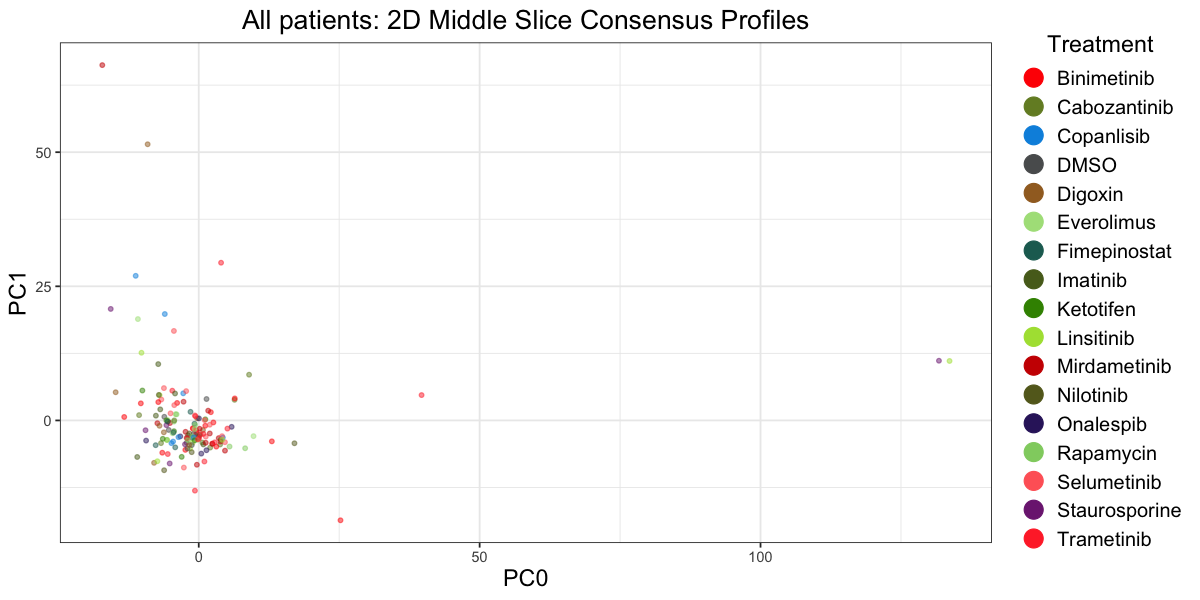

In [14]:
pca_cp_middle_plot <- (
    ggplot(middle_slice_2D_cp_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D Middle Slice Consensus Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme
    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_cp_middle_path <- file.path(figures_path, "2D", "middle_slice", "all_patients_2D_middle_slice_pca_consensus_features.png")
ggsave(pca_cp_middle_plot, file = pca_2d_cp_middle_path, width = width, height = height, dpi = 300)
pca_cp_middle_plot

## 3D PCA

feature selected facet by patients

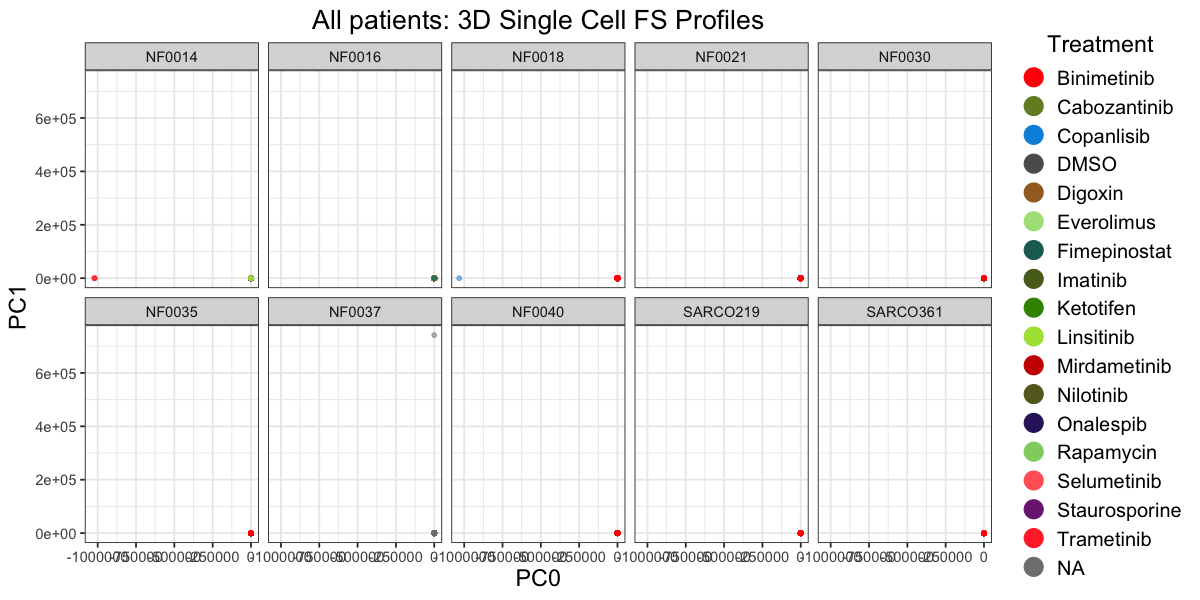

In [15]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(sc_3D_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 3D Single Cell FS Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
    + facet_wrap(~Metadata_patient, nrow = 2)
)
pca_3d_sc_faceted_path <- file.path(figures_path, "3D", "all_patients_3D_sc_features_facet_by_patient.png")
ggsave(pca_sc_plot, file = pca_3d_sc_faceted_path, width = width, height = height, dpi = 300)
pca_sc_plot

feature selected

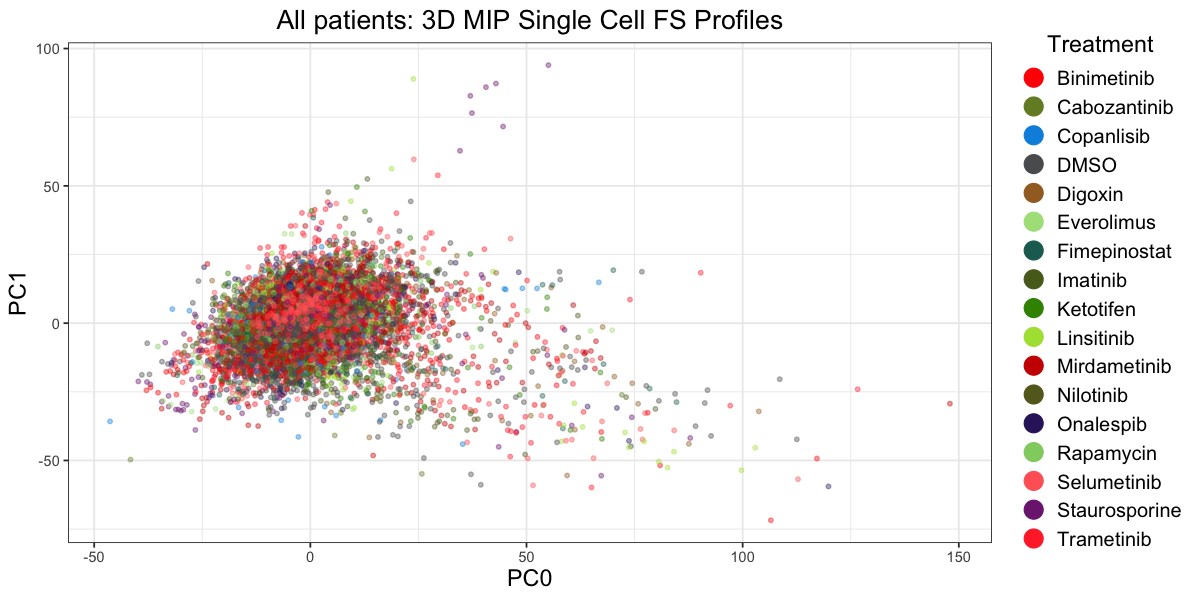

In [16]:
width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.4, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 3D MIP Single Cell FS Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_3d_sc_path <- file.path(figures_path, "3D", "all_patients_3D_pca_sc_features.png")
ggsave(pca_sc_plot, file = pca_3d_sc_path, width = width, height = height, dpi = 300)
pca_sc_plot

aggregate profiles

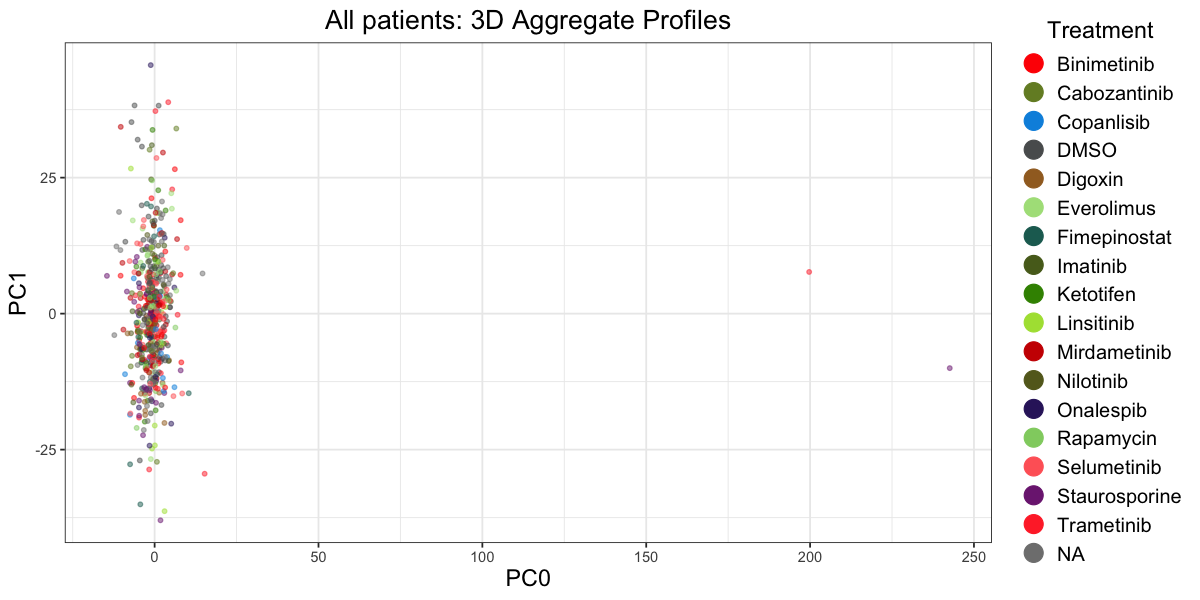

In [17]:
pca_agg_3d_plot <- (
    ggplot(agg_3D_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 3D Aggregate Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme
    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_3d_agg_path <- file.path(figures_path, "3D", "all_patients_3D_pca_agg_features.png")
ggsave(pca_agg_3d_plot, file = pca_3d_agg_path, width = width, height = height, dpi = 300)
pca_agg_3d_plot

consensus

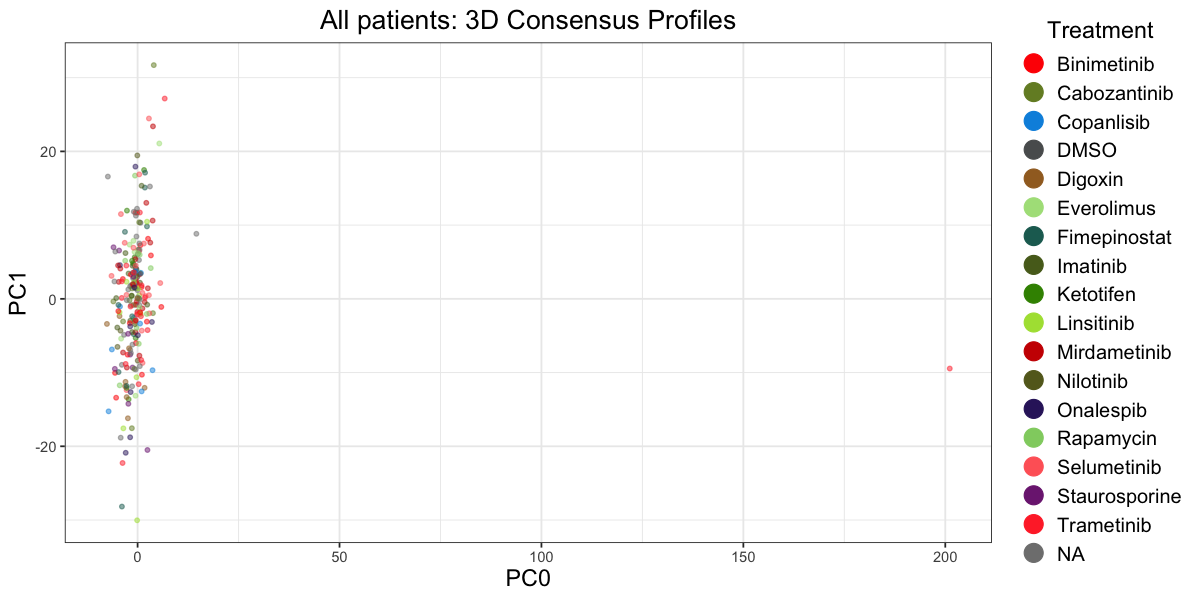

In [18]:
pca_cp_3d_plot <- (
    ggplot(cp_3D_pca_results, aes(x = PC0, y = PC1, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 3D Consensus Profiles", x = "PC0", y = "PC1")
    + theme_bw()
    + pca_theme
    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_3d_cp_path <- file.path(figures_path, "3D", "all_patients_3D_pca_consensus_features.png")
ggsave(pca_cp_3d_plot, file = pca_3d_cp_path, width = width, height = height, dpi = 300)
pca_cp_3d_plot